In [1]:
#import streamlit as st
import pandas as pd
import requests
import pyarrow.parquet as pq
import io

import matplotlib.pyplot as plt
import shap
import numpy as np

/home/mijka/.pyenv/versions/3.9.7/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
# Configuration de l'API
API_BASE_URL = "http://127.0.0.1:8000/"

# Fonction pour récupérer les données de l'API
def fetch_data(endpoint, params=None):
    # Utiliser la méthode HTTP correcte pour chaque point de terminaison
    if endpoint == '/data':
        response = requests.get(f"{API_BASE_URL}{endpoint}", params=params)
    elif endpoint == '/user_data':
        response = requests.post(f"{API_BASE_URL}{endpoint}", json=params)  # Utiliser POST pour /user_data
    elif endpoint == '/shap':
        response = requests.post(f"{API_BASE_URL}{endpoint}", json=params)  # Utiliser POST pour /shap
    else:
        response = requests.get(f"{API_BASE_URL}{endpoint}", params=params)

    if response.status_code == 200:
        if endpoint == '/data':
            return pq.read_table(io.BytesIO(response.content)).to_pandas()
        elif endpoint == '/shap':
            return response.json()
        else:
            return response.json()
    else:
        st.error(f"Error fetching data: {response.status_code}")
        return None

# Fonction pour envoyer une prédiction
def predict(data):
    response = requests.post(f"{API_BASE_URL}/predict", json=data)
    if response.status_code == 200:
        return response.json()
    else:
        st.error(f"Error making prediction: {response.status_code}")
        return None

# Chargement des données
data = fetch_data('/data')

In [21]:
data.columns

Index(['EXT_SOURCE_2', 'EXT_SOURCE_3', 'PAYMENT_RATE', 'INSTAL_DPD_MEAN',
       'INSTAL_AMT_PAYMENT_SUM', 'AMT_ANNUITY', 'DAYS_BIRTH', 'CODE_GENDER',
       'ANNUITY_INCOME_PERC', 'APPROVED_AMT_DOWN_PAYMENT_MAX',
       'DAYS_EMPLOYED_PERC', 'BURO_DAYS_CREDIT_MEAN', 'PREV_CNT_PAYMENT_MEAN',
       'AMT_GOODS_PRICE', 'BURO_AMT_CREDIT_SUM_DEBT_MEAN',
       'ACTIVE_DAYS_CREDIT_MAX', 'ACTIVE_DAYS_CREDIT_ENDDATE_MEAN',
       'PREV_APP_CREDIT_PERC_MEAN', 'INSTAL_PAYMENT_PERC_MEAN',
       'NAME_EDUCATION_TYPE_Highereducation', 'DAYS_ID_PUBLISH',
       'APPROVED_CNT_PAYMENT_MEAN', 'BURO_DAYS_CREDIT_MAX',
       'INSTAL_AMT_PAYMENT_MIN', 'INSTAL_DAYS_ENTRY_PAYMENT_SUM',
       'POS_MONTHS_BALANCE_SIZE', 'PREV_NAME_CONTRACT_STATUS_Refused_MEAN',
       'DAYS_REGISTRATION', 'PREV_APP_CREDIT_PERC_MIN',
       'APPROVED_DAYS_DECISION_MIN', 'INSTAL_AMT_PAYMENT_MEAN',
       'INSTAL_DBD_SUM', 'INSTAL_AMT_INSTALMENT_MAX', 'INCOME_CREDIT_PERC',
       'INSTAL_DAYS_ENTRY_PAYMENT_MEAN', 'INSTAL_PAYM

In [23]:
df = data.copy()
current_columns = df.columns.tolist()
current_columns.remove('SK_ID_CURR')
current_columns.remove('TARGET')
new_columns_order = ['SK_ID_CURR', 'TARGET'] + current_columns
df = df[new_columns_order]
df.head()

,SK_ID_CURR,TARGET,EXT_SOURCE_2,EXT_SOURCE_3,PAYMENT_RATE,INSTAL_DPD_MEAN,INSTAL_AMT_PAYMENT_SUM,AMT_ANNUITY,DAYS_BIRTH,CODE_GENDER,...,PREV_NAME_CONTRACT_STATUS_Refused_MEAN,DAYS_REGISTRATION,PREV_APP_CREDIT_PERC_MIN,APPROVED_DAYS_DECISION_MIN,INSTAL_AMT_PAYMENT_MEAN,INSTAL_DBD_SUM,INSTAL_AMT_INSTALMENT_MAX,INCOME_CREDIT_PERC,INSTAL_DAYS_ENTRY_PAYMENT_MEAN,INSTAL_PAYMENT_DIFF_MEAN
0,442623,0.0,0.595281,0.706205,0.039660,0.461538,7.992843e+05,53541.0,-16961,1,...,0.000000,-2108.0,1.137779,-2208.0,61483.410156,295.0,66693.781250,0.200000,-2021.538452,5050.211426
1,164728,0.0,0.656764,0.071055,0.032398,4.256757,2.602840e+06,30033.0,-12187,1,...,0.100000,-561.0,0.824513,-2604.0,35173.523438,897.0,922513.062500,0.145631,-1484.216187,8585.831055
2,136291,0.0,0.268461,0.256706,0.047191,0.125000,3.242952e+05,10737.0,-15445,0,...,0.000000,-1097.0,1.111116,-2289.0,13512.297852,113.0,13531.634766,0.395570,-1916.583374,0.000000
3,190853,0.0,0.675825,0.355639,0.067940,0.000000,6.519330e+04,30573.0,-13321,0,...,0.333333,-2951.0,1.000000,-2473.0,5926.663574,157.0,7696.529785,0.650000,-2305.454590,0.000000
4,198244,0.0,0.579739,0.363945,0.029348,0.000000,5.055732e+05,34578.0,-19486,0,...,0.200000,-6683.0,0.884721,-1049.0,25278.662109,289.0,190605.640625,0.103122,-559.349976,0.000000


In [3]:
data.head()

,EXT_SOURCE_2,EXT_SOURCE_3,PAYMENT_RATE,INSTAL_DPD_MEAN,INSTAL_AMT_PAYMENT_SUM,AMT_ANNUITY,DAYS_BIRTH,CODE_GENDER,ANNUITY_INCOME_PERC,APPROVED_AMT_DOWN_PAYMENT_MAX,...,PREV_APP_CREDIT_PERC_MIN,APPROVED_DAYS_DECISION_MIN,INSTAL_AMT_PAYMENT_MEAN,INSTAL_DBD_SUM,INSTAL_AMT_INSTALMENT_MAX,INCOME_CREDIT_PERC,INSTAL_DAYS_ENTRY_PAYMENT_MEAN,INSTAL_PAYMENT_DIFF_MEAN,SK_ID_CURR,TARGET
0,0.595281,0.706205,0.039660,0.461538,7.992843e+05,53541.0,-16961,1,0.198300,90000.0,...,1.137779,-2208.0,61483.410156,295.0,66693.781250,0.200000,-2021.538452,5050.211426,442623,0.0
1,0.656764,0.071055,0.032398,4.256757,2.602840e+06,30033.0,-12187,1,0.222467,14931.0,...,0.824513,-2604.0,35173.523438,897.0,922513.062500,0.145631,-1484.216187,8585.831055,164728,0.0
2,0.268461,0.256706,0.047191,0.125000,3.242952e+05,10737.0,-15445,0,0.119300,22441.5,...,1.111116,-2289.0,13512.297852,113.0,13531.634766,0.395570,-1916.583374,0.000000,136291,0.0
3,0.675825,0.355639,0.067940,0.000000,6.519330e+04,30573.0,-13321,0,0.104523,4500.0,...,1.000000,-2473.0,5926.663574,157.0,7696.529785,0.650000,-2305.454590,0.000000,190853,0.0
4,0.579739,0.363945,0.029348,0.000000,5.055732e+05,34578.0,-19486,0,0.284593,45000.0,...,0.884721,-1049.0,25278.662109,289.0,190605.640625,0.103122,-559.349976,0.000000,198244,0.0


In [5]:
# Réorganiser les colonnes pour afficher SK_ID_CURR en premier
cols = ['SK_ID_CURR'] + [col for col in data.columns if col != 'SK_ID_CURR']
data = data[cols]


# Convertir SK_ID_CURR en int natif
data['SK_ID_CURR'] = data['SK_ID_CURR'].astype(int)

In [6]:
# Sélection d'un utilisateur
#user_id = st.selectbox("Sélectionnez un utilisateur", data['SK_ID_CURR'])
user_id = 442623

In [8]:
# Affichage des données de l'utilisateur sélectionné
user_data = fetch_data('/user_data', params={'SK_ID_CURR': user_id})

In [9]:
user_data

[{'EXT_SOURCE_2': 0.595280647277832,
  'EXT_SOURCE_3': 0.7062051296234131,
  'PAYMENT_RATE': 0.039659999310970306,
  'INSTAL_DPD_MEAN': 0.4615384638309479,
  'INSTAL_AMT_PAYMENT_SUM': 799284.3125,
  'AMT_ANNUITY': 53541.0,
  'DAYS_BIRTH': -16961,
  'CODE_GENDER': 1,
  'ANNUITY_INCOME_PERC': 0.19830000400543213,
  'APPROVED_AMT_DOWN_PAYMENT_MAX': 90000.0,
  'DAYS_EMPLOYED_PERC': 0.24149519205093384,
  'BURO_DAYS_CREDIT_MEAN': -1695.3333740234375,
  'PREV_CNT_PAYMENT_MEAN': 12.0,
  'AMT_GOODS_PRICE': 1350000.0,
  'BURO_AMT_CREDIT_SUM_DEBT_MEAN': 3197173.5,
  'ACTIVE_DAYS_CREDIT_MAX': -252.0,
  'ACTIVE_DAYS_CREDIT_ENDDATE_MEAN': 3401.0,
  'PREV_APP_CREDIT_PERC_MEAN': 1.1377789974212646,
  'INSTAL_PAYMENT_PERC_MEAN': 0.9230769276618958,
  'NAME_EDUCATION_TYPE_Highereducation': 1,
  'DAYS_ID_PUBLISH': -497,
  'APPROVED_CNT_PAYMENT_MEAN': 12.0,
  'BURO_DAYS_CREDIT_MAX': -252.0,
  'INSTAL_AMT_PAYMENT_MIN': 2652.75,
  'INSTAL_DAYS_ENTRY_PAYMENT_SUM': -26280.0,
  'POS_MONTHS_BALANCE_SIZE': 12.0

In [12]:
# Prédiction
user_data_df = pd.DataFrame(user_data)
prediction_data = user_data_df.drop(columns=['SK_ID_CURR', 'TARGET']).to_dict(orient='records')[0]
prediction_data

{'EXT_SOURCE_2': 0.595280647277832,
 'EXT_SOURCE_3': 0.7062051296234131,
 'PAYMENT_RATE': 0.039659999310970306,
 'INSTAL_DPD_MEAN': 0.4615384638309479,
 'INSTAL_AMT_PAYMENT_SUM': 799284.3125,
 'AMT_ANNUITY': 53541.0,
 'DAYS_BIRTH': -16961,
 'CODE_GENDER': 1,
 'ANNUITY_INCOME_PERC': 0.19830000400543213,
 'APPROVED_AMT_DOWN_PAYMENT_MAX': 90000.0,
 'DAYS_EMPLOYED_PERC': 0.24149519205093384,
 'BURO_DAYS_CREDIT_MEAN': -1695.3333740234375,
 'PREV_CNT_PAYMENT_MEAN': 12.0,
 'AMT_GOODS_PRICE': 1350000.0,
 'BURO_AMT_CREDIT_SUM_DEBT_MEAN': 3197173.5,
 'ACTIVE_DAYS_CREDIT_MAX': -252.0,
 'ACTIVE_DAYS_CREDIT_ENDDATE_MEAN': 3401.0,
 'PREV_APP_CREDIT_PERC_MEAN': 1.1377789974212646,
 'INSTAL_PAYMENT_PERC_MEAN': 0.9230769276618958,
 'NAME_EDUCATION_TYPE_Highereducation': 1,
 'DAYS_ID_PUBLISH': -497,
 'APPROVED_CNT_PAYMENT_MEAN': 12.0,
 'BURO_DAYS_CREDIT_MAX': -252.0,
 'INSTAL_AMT_PAYMENT_MIN': 2652.75,
 'INSTAL_DAYS_ENTRY_PAYMENT_SUM': -26280.0,
 'POS_MONTHS_BALANCE_SIZE': 12.0,
 'PREV_NAME_CONTRACT_STA

In [14]:
prediction = predict(prediction_data)
if prediction is not None:
    print(f"Prédiction pour l'utilisateur {user_id} : {prediction}")

Prédiction pour l'utilisateur 442623 : {'prediction': [0.0]}


In [18]:
int(prediction['prediction'][0])

0

In [24]:

# Affichage des données SHAP
shap_data = fetch_data('/shap', params={'SK_ID_CURR': user_id})

In [25]:
shap_data

[{'EXT_SOURCE_2': -0.09884810711278333,
  'EXT_SOURCE_3': -0.9087273810548296,
  'PAYMENT_RATE': -0.4862894508062103,
  'INSTAL_DPD_MEAN': -0.0038103171121508755,
  'INSTAL_AMT_PAYMENT_SUM': -0.5164578030072821,
  'AMT_ANNUITY': 0.2787360971885895,
  'DAYS_BIRTH': 0.21096897889990812,
  'CODE_GENDER': -0.41697294025361276,
  'ANNUITY_INCOME_PERC': 0.07246233215172414,
  'APPROVED_AMT_DOWN_PAYMENT_MAX': -0.40851885085710987,
  'DAYS_EMPLOYED_PERC': -0.1829500406128059,
  'BURO_DAYS_CREDIT_MEAN': -0.4326394508588534,
  'PREV_CNT_PAYMENT_MEAN': -0.09713726458832095,
  'AMT_GOODS_PRICE': -0.9069609235551122,
  'BURO_AMT_CREDIT_SUM_DEBT_MEAN': -0.5325417567285784,
  'ACTIVE_DAYS_CREDIT_MAX': 0.02442001880829064,
  'ACTIVE_DAYS_CREDIT_ENDDATE_MEAN': 0.07732741274793546,
  'PREV_APP_CREDIT_PERC_MEAN': -0.058288799930034024,
  'INSTAL_PAYMENT_PERC_MEAN': -0.4768370469975532,
  'NAME_EDUCATION_TYPE_Highereducation': -0.6946742617880585,
  'DAYS_ID_PUBLISH': -0.6446111853859515,
  'APPROVED_CNT_

In [26]:
# Convertir les données SHAP en un format compatible avec shap
shap_values = shap_data[0]['shap_values']
expected_values = shap_data[0]['expected_values']
feature_names = list(shap_data[0]['feature_names'])

# Créer un objet Explanation de SHAP
expl = shap.Explanation(values=np.array(shap_values),
                        base_values=np.array(expected_values),
                        feature_names=feature_names)

# Visualiser les valeurs SHAP
fig, ax = plt.subplots()
shap.plots.bar(expl, show=False)
st.pyplot(fig)

KeyError: 'shap_values'

DeltaGenerator(_root_container=0, _provided_cursor=None, _parent=None, _block_type=None, _form_data=None)

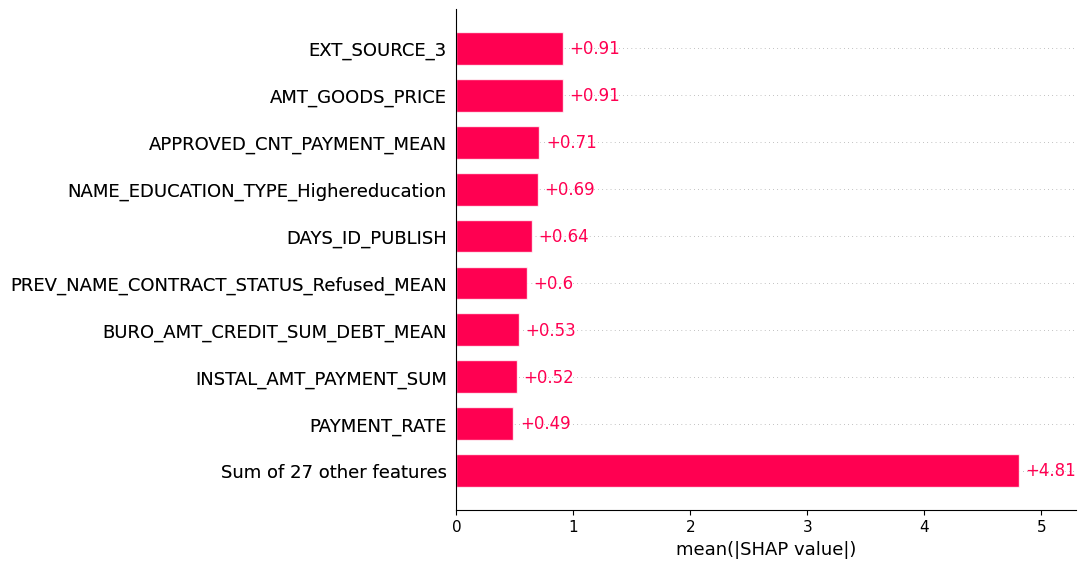

In [35]:
# Extraire les valeurs SHAP et les noms des caractéristiques
shap_values = np.array([list(shap_data[0].values())])
feature_names = list(shap_data[0].keys())
expected_values = np.zeros(len(feature_names))  # Vous pouvez remplacer cela par les valeurs de base réelles si disponibles

# Créer un objet Explanation de SHAP
expl = shap.Explanation(values=shap_values,
                         base_values=expected_values,
                         feature_names=feature_names)

# Visualiser les valeurs SHAP
fig, ax = plt.subplots()
shap.plots.bar(expl, show=False)
st.pyplot(fig)